# 21M.369 Final Project Code


In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import ipywidgets as widgets
import copy
import os
from IPython.display import display

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
c1 = "#CC4331"
c2 = "#0D3B66"

## Load Data

In [2]:
data_dir = "C:/Users/Cassidy/OneDrive - Massachusetts Institute of Technology/Desktop/classes/21M.369/Final Project/data_analysis/measurements/"
plots_dir = "C:/Users/Cassidy/OneDrive - Massachusetts Institute of Technology/Desktop/classes/21M.369/Final Project/data_analysis/plots/"

data = {
    1: {"aperture": 13.17, "files": ["MinCircle_1", "MinCircle_2", "MinCircle_3"]},
    2: {"aperture": 23.79, "files": ["23Circle_1", "23Circle_2", "23Circle_3"]},
    3: {"aperture": 33.95, "files": ["33Circle_1", "33Circle_2", "33Circle_3"]},
    4: {"aperture": 43.63, "files": ["43Circle_1", "43Circle_2", "43Circle_3"]},
    5: {"aperture": 53.76, "files": ["53Circle_1", "53Circle_2", "53Circle_3"]},
    6: {"aperture": 63.60, "files": ["63Circle_1", "63Circle_2", "63Circle_3"]},
    7: {"aperture": 73.62, "files": ["73Circle_1", "73Circle_2", "73Circle_3"]},
    8: {"aperture": 83.65, "files": ["83Circle_1", "83Circle_2", "83Circle_3"]},
    9: {"aperture": 92.88, "files": ["93Circle_1", "93Circle_2", "93Circle_3"]},
    10: {"aperture": 100.72, "files": ["FullCircle_2", "FullCircle_3", "FullCircle_4"]},
}


def inspect_file(file_path):
    mat = sio.loadmat(file_path, squeeze_me=True)
    print("Keys in file:")
    for k, v in mat.items():
        if k.startswith("__"):
            continue
        shape = getattr(v, "shape", "scalar")
        dtype = getattr(v, "dtype", type(v).__name__)
        print(f"  {k}: shape={shape}, dtype={dtype}")


mat_path = data_dir + data[1]["files"][0]
inspect_file(mat_path)

Keys in file:
  buflen: shape=scalar, dtype=int
  channelNames: shape=(2,), dtype=object
  dt2: shape=(3,), dtype=uint8
  freq: shape=scalar, dtype=int
  indata: shape=(192000, 2), dtype=float64
  npts: shape=scalar, dtype=int
  tsmax: shape=scalar, dtype=float
  yspec: shape=(131073, 2), dtype=complex128


### Extract Signals

In [3]:
def load_hammer_test(mat_path):
    mat = sio.loadmat(mat_path, squeeze_me=True)

    fs = float(mat['freq'])
    indata = mat['indata']           # (192000, 2) — actual samples
    yspec = mat['yspec']             # (131073, 2) — precomputed FFT

    F = indata[:, 0]   # hammer force (N)
    v = indata[:, 1]   # velocity (m/s)
    npts_actual = len(F)
    t = np.arange(npts_actual) / fs

    nfreq = yspec.shape[0]           # 131073
    freqs_pre = np.linspace(0, fs/2, nfreq)
    F_fft_pre = yspec[:, 0]
    V_fft_pre = yspec[:, 1]

    print(f"fs = {fs} Hz, actual samples = {npts_actual}, duration = {npts_actual/fs:.3f} s")
    print(f"FFT bins = {nfreq}, freq resolution = {(fs/2)/(nfreq-1):.4f} Hz")

    return {
        't': t, 'F': F, 'v': v, 'fs': fs,
        'freqs_pre': freqs_pre, 'F_fft_pre': F_fft_pre, 'V_fft_pre': V_fft_pre,
    }


d = load_hammer_test(mat_path)
t, F, v, fs = d['t'], d['F'], d['v'], d['fs']

fs = 48000.0 Hz, actual samples = 192000, duration = 4.000 s
FFT bins = 131073, freq resolution = 0.1831 Hz


## Collect and Plot Data

### Plot Time-Domain Signals

fs = 48000.0 Hz, actual samples = 192000, duration = 4.000 s
FFT bins = 131073, freq resolution = 0.1831 Hz


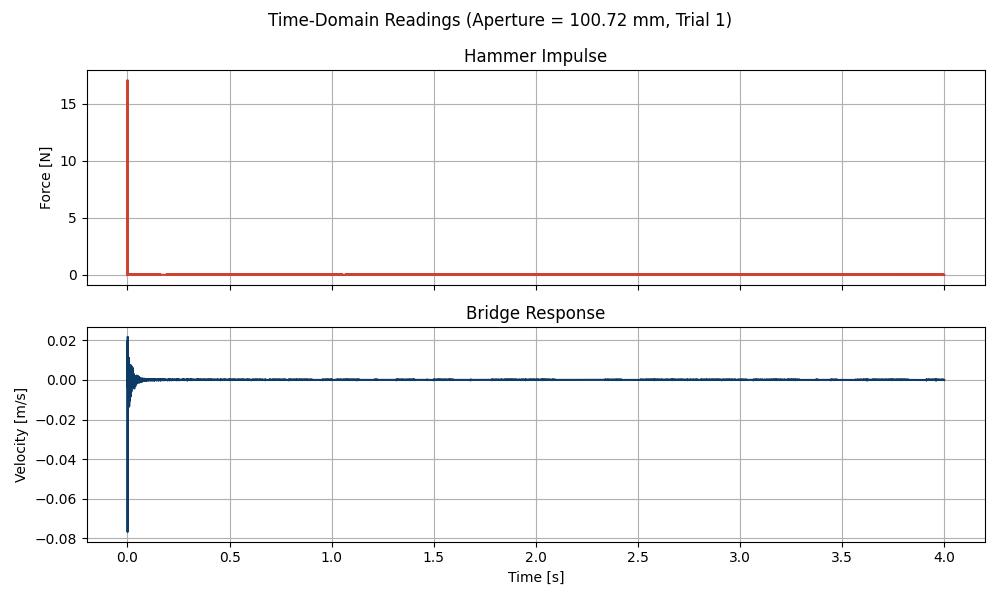

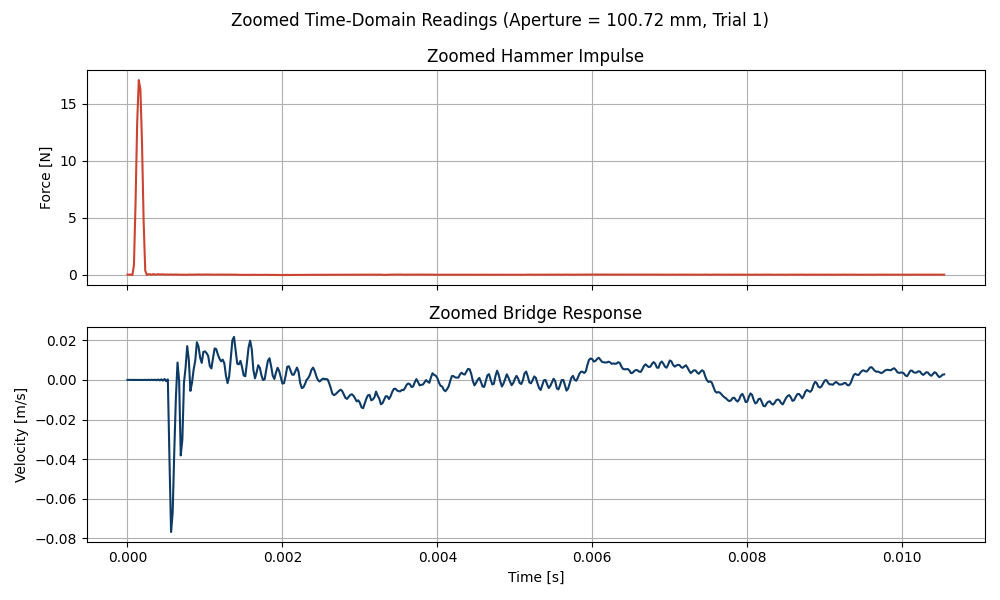

fs = 48000.0 Hz, actual samples = 192000, duration = 4.000 s
FFT bins = 131073, freq resolution = 0.1831 Hz


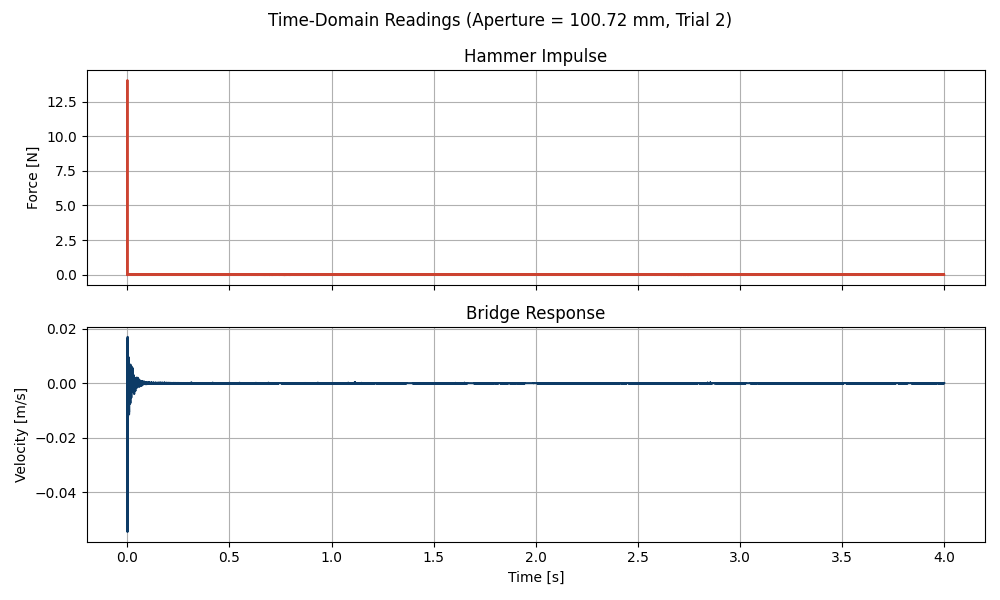

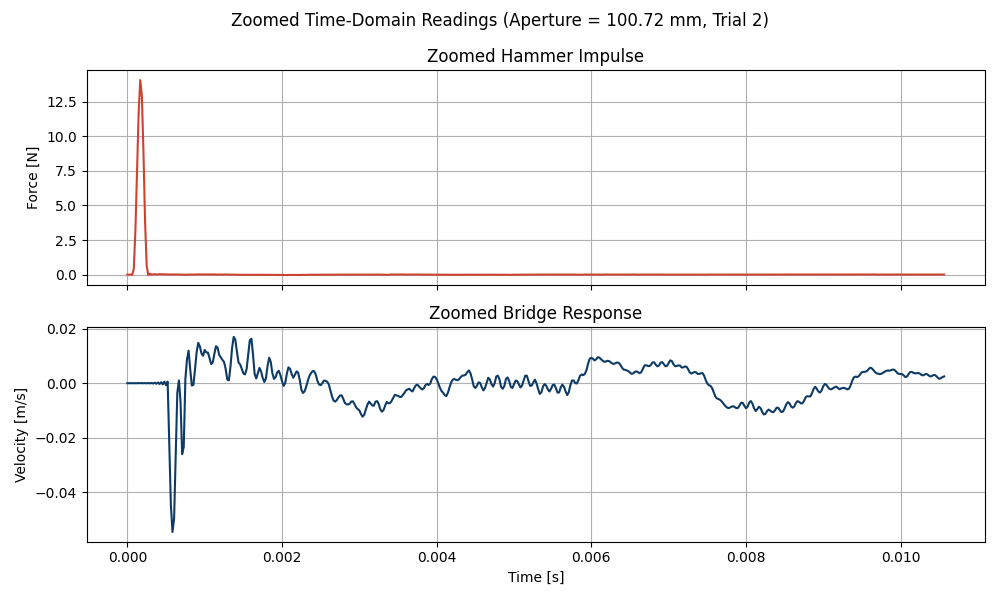

fs = 48000.0 Hz, actual samples = 192000, duration = 4.000 s
FFT bins = 131073, freq resolution = 0.1831 Hz


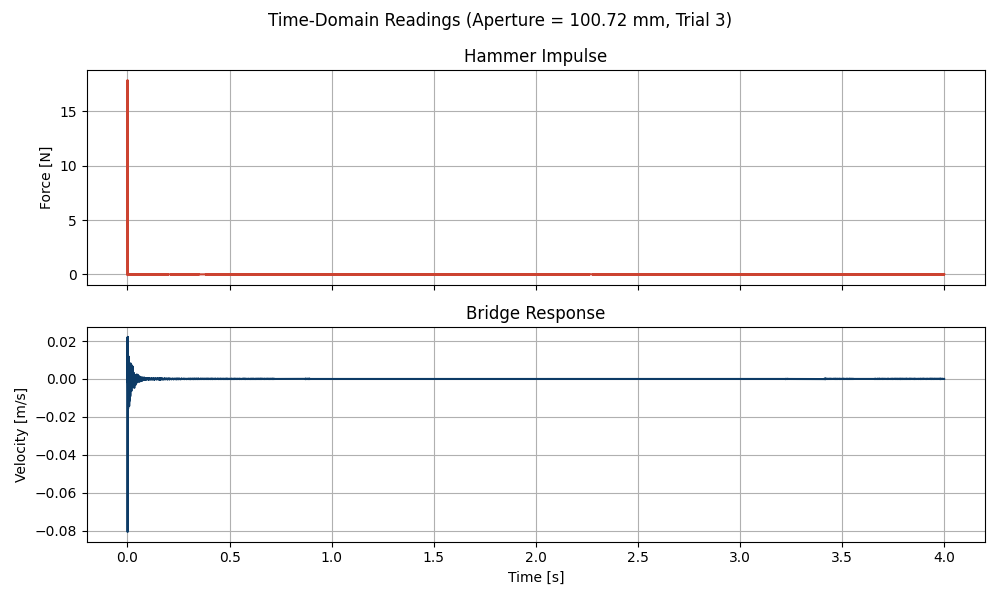

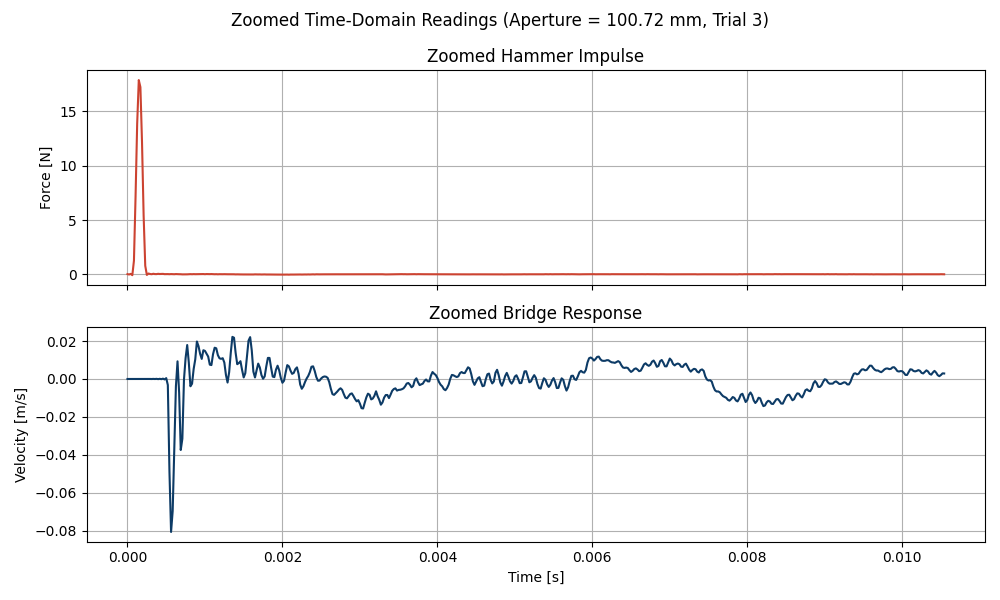

In [16]:
def plot_time_domain(hammer_test, aperture_size, trial_num=None, save_path=None, zoom=True):
    # Extract time-domain data
    t, F, v, fs = hammer_test['t'], hammer_test['F'], hammer_test['v'], hammer_test['fs']

    # Make plots
    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
    ax[0].plot(t, F, color=c1)
    ax[0].set_ylabel('Force [N]')
    ax[0].set_title('Hammer Impulse')

    ax[1].plot(t, v, color=c2)
    ax[1].set_ylabel('Velocity [m/s]')
    ax[1].set_xlabel('Time [s]')
    ax[1].set_title('Bridge Response')


    fig_title = f"Time-Domain Readings (Aperture = {aperture_size} mm"
    if trial_num:
        fig_title += f", Trial {trial_num})"
    else:
        fig_title += ")"

    fig.suptitle(fig_title)

    plt.tight_layout()

    # Save wide view plot
    if save_path:
        fname = "time_dom"
        if trial_num:
            fname += f"_{trial_num}"
        plt.savefig(save_path + "/" + fname + ".png")

    plt.show()

    if zoom:
        # Zoom on the impulse to verify it's a clean single hit
        peak_idx = np.argmax(np.abs(F))
        window = slice(max(0, peak_idx-100), peak_idx+500)
        fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
        ax[0].plot(t[window], F[window], color=c1)
        ax[0].set_ylabel('Force [N]')
        ax[0].set_title('Zoomed Hammer Impulse')

        ax[1].plot(t[window], v[window], color=c2)
        ax[1].set_ylabel('Velocity [m/s]')
        ax[1].set_xlabel('Time [s]')
        ax[1].set_title('Zoomed Bridge Response')

        plt.suptitle(f'Zoomed {fig_title}')

        plt.tight_layout()

        # Save zoomed plot
        if save_path:
            os.makedirs(save_path, exist_ok=True)
            zfname = "zoom_time_dom"
            if trial_num:
                zfname += f"_{trial_num}"
            plt.savefig(save_path + "/" + zfname + ".png")

        plt.show()


mat_paths = data[10]["files"]
aperture_size = data[10]["aperture"]

for i, file_name in enumerate(mat_paths):
    mat_path = data_dir + file_name

    d = load_hammer_test(mat_path)
    save_path = plots_dir + "aper_100" + "/time_domain"
    plot_time_domain(d, aperture_size, trial_num=i+1, save_path=save_path)

### Plot Frequency-Domain Signals

fs = 48000.0 Hz, actual samples = 192000, duration = 4.000 s
FFT bins = 131073, freq resolution = 0.1831 Hz


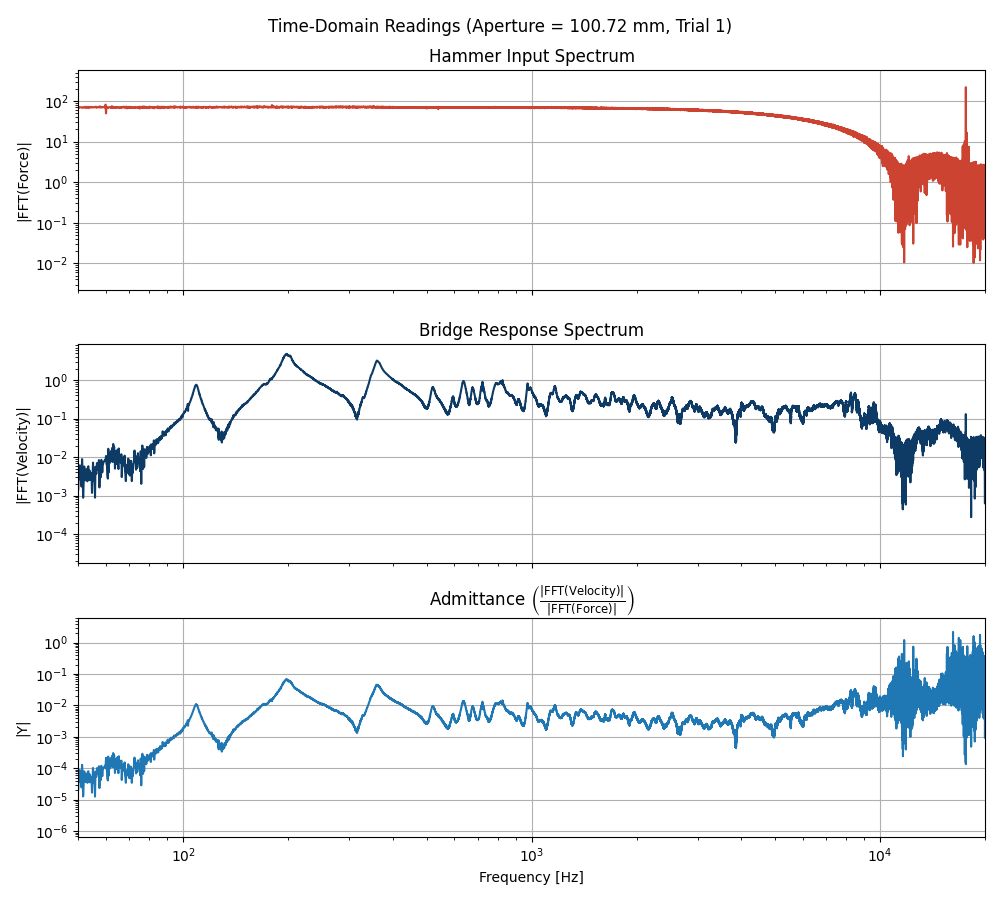

fs = 48000.0 Hz, actual samples = 192000, duration = 4.000 s
FFT bins = 131073, freq resolution = 0.1831 Hz


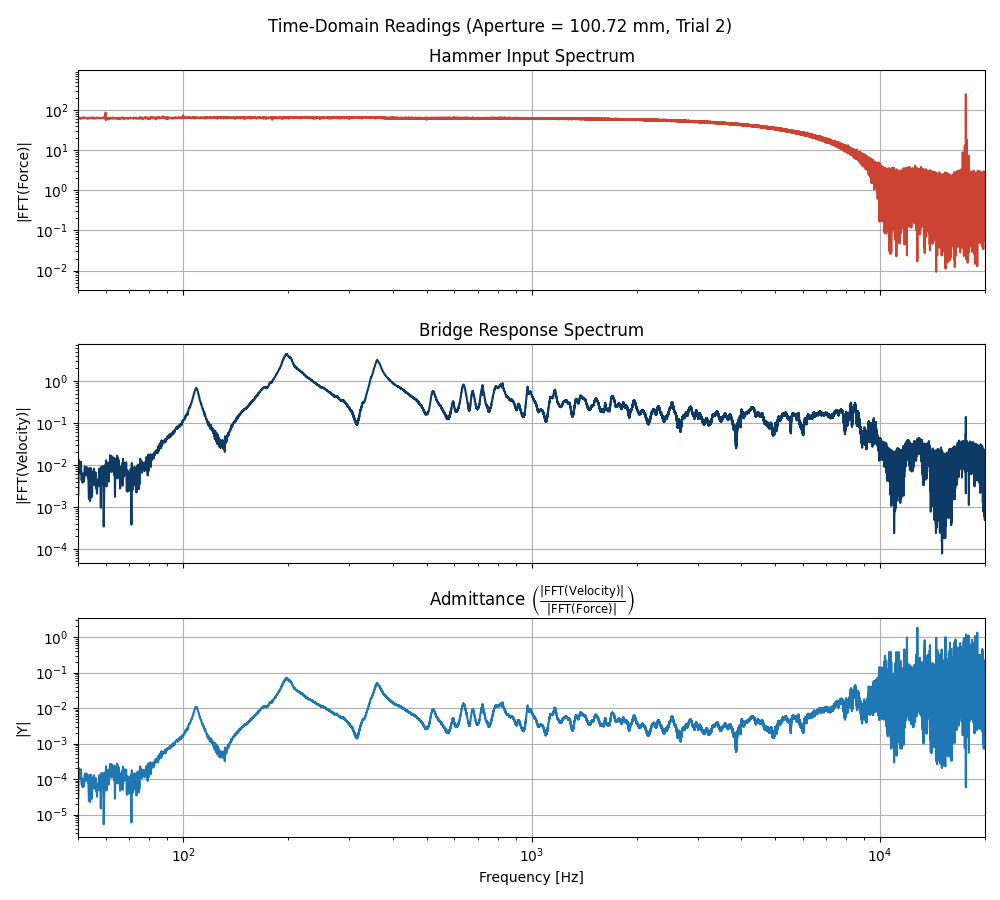

fs = 48000.0 Hz, actual samples = 192000, duration = 4.000 s
FFT bins = 131073, freq resolution = 0.1831 Hz


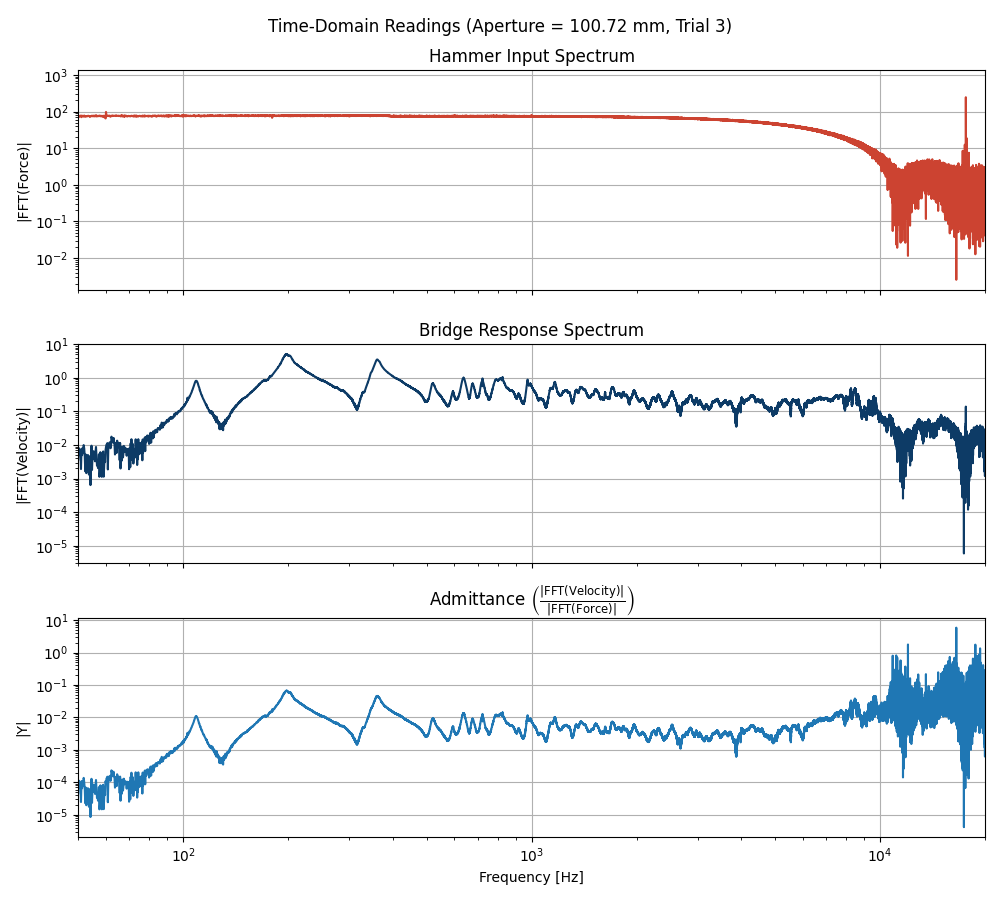

In [ ]:
def plot_freq_domain(hammer_test, aperture_size, trial_num=None, save_path=None):

    # Admittance from precomputed FFT
    Y = hammer_test['V_fft_pre'] / hammer_test['F_fft_pre']
    freqs = hammer_test['freqs_pre']

    # Make plots
    fig, ax = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

    ax[0].semilogy(freqs, np.abs(hammer_test['F_fft_pre']), color=c1)
    ax[0].set_ylabel('|FFT(Force)|')
    ax[0].set_title('Hammer Input Spectrum')

    ax[1].semilogy(freqs, np.abs(hammer_test['V_fft_pre']), color=c2)
    ax[1].set_ylabel('|FFT(Velocity)|')
    ax[1].set_title('Bridge Response Spectrum')

    ax[2].semilogy(freqs, np.abs(Y))
    ax[2].set_ylabel('|Y|')
    ax[2].set_xlabel('Frequency [Hz]')
    ax[2].set_xscale('log')
    ax[2].set_xlim(50, 20000)
    ax[2].set_title(r'Admittance $\left(\frac{|\text{FFT(Velocity)}|}{|\text{FFT(Force)}|}\right)$')

    fig_title = f"Time-Domain Readings (Aperture = {aperture_size} mm"
    if trial_num:
        fig_title += f", Trial {trial_num})"
    else:
        fig_title += ")"
    fig.suptitle(fig_title)

    plt.tight_layout()

    # Save plot
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        fname = "freq_dom"
        if trial_num:
            fname += f"_{trial_num}"
        plt.savefig(save_path + "/" + fname + ".png")

    plt.show()


mat_paths = data[10]["files"]
aperture_size = data[10]["aperture"]

for i, file_name in enumerate(mat_paths):
    mat_path = data_dir + file_name

    d = load_hammer_test(mat_path)
    save_path = plots_dir + "aper_100" + "/freq_domain"

    plot_freq_domain(d, aperture_size, trial_num=i+1, save_path=save_path)


### Manual Peak Detection

Run this first to log all of the resonant peaks for analysis later.

In [35]:
all_points = {}

fs = 48000.0 Hz, actual samples = 192000, duration = 4.000 s
FFT bins = 131073, freq resolution = 0.1831 Hz


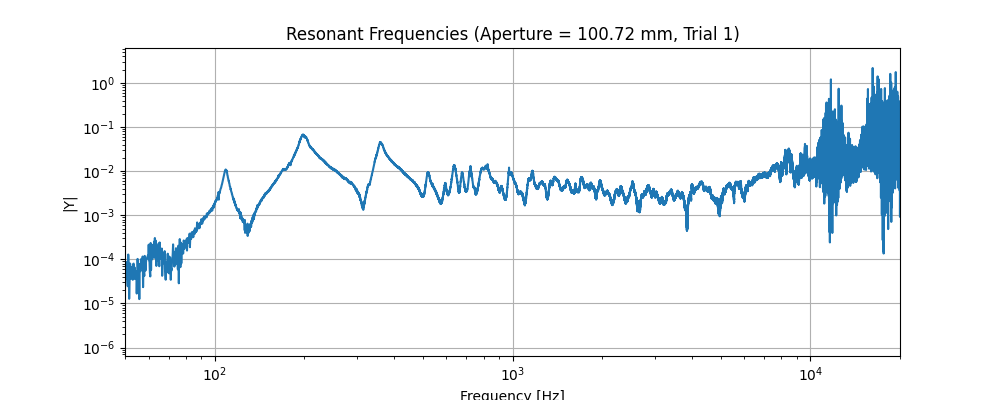

fs = 48000.0 Hz, actual samples = 192000, duration = 4.000 s
FFT bins = 131073, freq resolution = 0.1831 Hz


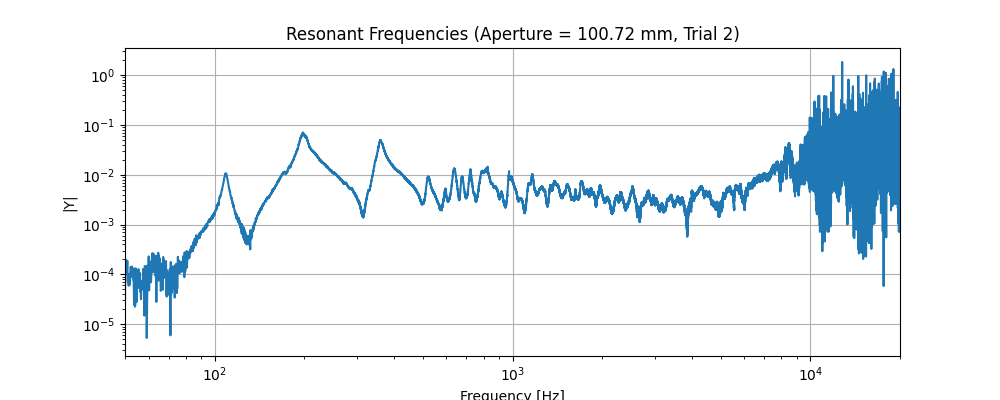

fs = 48000.0 Hz, actual samples = 192000, duration = 4.000 s
FFT bins = 131073, freq resolution = 0.1831 Hz


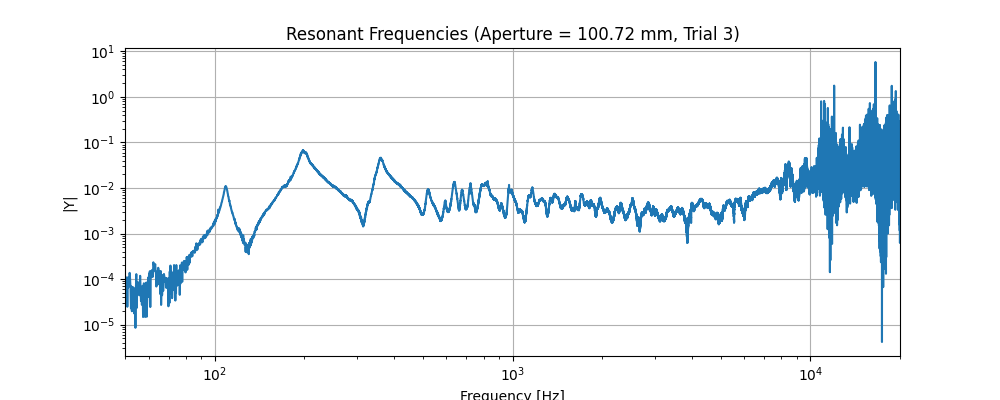

In [ ]:
def plot_admittance(hammer_test, aperture_size, out_points, trial_num=None, save_path=None):
    Y = hammer_test['V_fft_pre'] / hammer_test['F_fft_pre']
    freqs = hammer_test['freqs_pre']

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.set_ylabel('|Y|')

    ax.semilogy(freqs, np.abs(Y))
    ax.set_xlabel('Frequency [Hz]')
    ax.set_xscale('log')
    ax.set_xlim(50, 20000)

    fig_title = f"Resonant Frequencies (Aperture = {aperture_size} mm"
    if trial_num:
        fig_title += f", Trial {trial_num})"
    else:
        fig_title += ")"
    ax.set_title(fig_title)

    # Temporary storage for markers and data
    temp_points = []
    temp_artists = []

    def onclick(event):
        if event.xdata is not None:
            # Save data
            temp_points.append((event.xdata, event.ydata))
            # Draw on plot
            p, = ax.plot(event.xdata, event.ydata, color=c1, marker="o")
            ann = ax.annotate(f"({event.xdata:.1f}, {event.ydata:.2f})", (event.xdata, event.ydata),
                              xytext=(0,10), textcoords="offset points", ha='center', fontsize="small")
            temp_artists.extend([p, ann])
            fig.canvas.draw()

    # Widget Buttons for control
    btn_confirm = widgets.Button(description="Confirm Points", button_style='success')
    btn_reset = widgets.Button(description="Reset Plot", button_style='danger')

    def on_confirm(b):
        out_points.extend(temp_points)
        print(f"Stored points: {out_points}")
        # Optional: stop interaction
        fig.canvas.mpl_disconnect(cid)

        # Save plot
        if save_path:
            os.makedirs(save_path, exist_ok=True)
            fname = "res_freqs"
            if trial_num:
                fname += f"_{trial_num}"
            fig.savefig(save_path + "/" + fname + ".png", bbox_inches='tight')

    def on_reset(b):
        temp_points.clear()
        for artist in temp_artists:
            artist.remove()
        temp_artists.clear()
        fig.canvas.draw()

    btn_confirm.on_click(on_confirm)
    btn_reset.on_click(on_reset)

    # Display plot and buttons together
    cid = fig.canvas.mpl_connect('button_press_event', onclick)
    display(widgets.HBox([btn_confirm, btn_reset]))
    plt.show()


mat_paths = data[10]["files"]
aperture_size = data[10]["aperture"]

for i, file_name in enumerate(mat_paths):
    mat_path = data_dir + file_name
    save_path = plots_dir + "aper_100" + "/res_freqs"
    all_points[file_name] = []

    d = load_hammer_test(mat_path)

    plot_admittance(d, aperture_size, all_points[file_name], trial_num=i+1, save_path=save_path)


In [53]:
print(all_points.keys())

print(all_points["FullCircle_2"], all_points["FullCircle_3"], all_points["FullCircle_4"])

dict_keys(['MinCircle_1', 'MinCircle_2', 'MinCircle_3', '23Circle_1', '23Circle_2', '23Circle_3', '33Circle_1', '33Circle_2', '33Circle_3', '43Circle_1', '43Circle_2', '43Circle_3', '53Circle_1', '53Circle_2', '53Circle_3', '63Circle_1', '63Circle_2', '63Circle_3', '73Circle_1', '73Circle_2', '73Circle_3', '83Circle_1', '83Circle_2', '83Circle_3', '93Circle_1', '93Circle_2', '93Circle_3', 'FullCircle_2', 'FullCircle_3', 'FullCircle_4'])
[(np.float64(108.49036485541002), np.float64(0.010527221049195498)), (np.float64(198.2786335418085), np.float64(0.06547157677538858)), (np.float64(356.8171098910604), np.float64(0.0454260514768928))] [(np.float64(109.33234907893832), np.float64(0.011285315737895756)), (np.float64(198.27863938926882), np.float64(0.07169978928575584)), (np.float64(356.81712041399936), np.float64(0.04953555649295881))] [(np.float64(109.33234907893832), np.float64(0.00989029021556578)), (np.float64(198.27863938926882), np.float64(0.06420338672945795)), (np.float64(359.58633

## Results

In [54]:
results = copy.deepcopy(data)

for trial in range(1, 11):
    file_names = data[trial]["files"]
    n = len(file_names)

    f_0 = sum(all_points[f][0][0] for f in file_names) / n
    f_1 = sum(all_points[f][1][0] for f in file_names) / n
    f_2 = sum(all_points[f][2][0] for f in file_names) / n

    results[trial]["freqs"] = {"f_0": f_0, "f_1": f_1, "f_2": f_2}

    print("APERTURE SIZE: ", data[trial]["aperture"])
    print("RESONANT FREQUENCIES: ", results[trial]["freqs"])
    print()

APERTURE SIZE:  13.17
RESONANT FREQUENCIES:  {'f_0': np.float64(62.34219558618454), 'f_1': np.float64(188.80550862198024), 'f_2': np.float64(359.5934965605331)}

APERTURE SIZE:  23.79
RESONANT FREQUENCIES:  {'f_0': np.float64(62.6639201713623), 'f_1': np.float64(189.29519814915065), 'f_2': np.float64(358.6632607646649)}

APERTURE SIZE:  33.95
RESONANT FREQUENCIES:  {'f_0': np.float64(73.89897191566956), 'f_1': np.float64(190.76429785896335), 'f_2': np.float64(359.5935000954017)}

APERTURE SIZE:  43.63
RESONANT FREQUENCIES:  {'f_0': np.float64(82.77111233325763), 'f_1': np.float64(189.7811165063798), 'f_2': np.float64(358.6632607646649)}

APERTURE SIZE:  53.76
RESONANT FREQUENCIES:  {'f_0': np.float64(90.12512255108851), 'f_1': np.float64(191.25778780912924), 'f_2': np.float64(358.67042815263454)}

APERTURE SIZE:  63.6
RESONANT FREQUENCIES:  {'f_0': np.float64(95.86937192916962), 'f_1': np.float64(193.2394647439891), 'f_2': np.float64(360.5237323289673)}

APERTURE SIZE:  73.62
RESONANT 

In [76]:
# print(results)

# Analysis results was the printed value for results
analysis_results = {
    1: {
        "aperture": 13.17,
        "files": ["MinCircle_1", "MinCircle_2", "MinCircle_3"],
        "freqs": {
            "f_0": np.float64(62.34219558618454),
            "f_1": np.float64(188.80550862198024),
            "f_2": np.float64(359.5934965605331),
        },
    },
    2: {
        "aperture": 23.79,
        "files": ["23Circle_1", "23Circle_2", "23Circle_3"],
        "freqs": {
            "f_0": np.float64(62.6639201713623),
            "f_1": np.float64(189.29519814915065),
            "f_2": np.float64(358.6632607646649),
        },
    },
    3: {
        "aperture": 33.95,
        "files": ["33Circle_1", "33Circle_2", "33Circle_3"],
        "freqs": {
            "f_0": np.float64(73.89897191566956),
            "f_1": np.float64(190.76429785896335),
            "f_2": np.float64(359.5935000954017),
        },
    },
    4: {
        "aperture": 43.63,
        "files": ["43Circle_1", "43Circle_2", "43Circle_3"],
        "freqs": {
            "f_0": np.float64(82.77111233325763),
            "f_1": np.float64(189.7811165063798),
            "f_2": np.float64(358.6632607646649),
        },
    },
    5: {
        "aperture": 53.76,
        "files": ["53Circle_1", "53Circle_2", "53Circle_3"],
        "freqs": {
            "f_0": np.float64(90.12512255108851),
            "f_1": np.float64(191.25778780912924),
            "f_2": np.float64(358.67042815263454),
        },
    },
    6: {
        "aperture": 63.6,
        "files": ["63Circle_1", "63Circle_2", "63Circle_3"],
        "freqs": {
            "f_0": np.float64(95.86937192916962),
            "f_1": np.float64(193.2394647439891),
            "f_2": np.float64(360.5237323289673),
        },
    },
    7: {
        "aperture": 73.62,
        "files": ["73Circle_1", "73Circle_2", "73Circle_3"],
        "freqs": {
            "f_0": np.float64(101.20043139814429),
            "f_1": np.float64(196.75559251197888),
            "f_2": np.float64(360.51657203816876),
        },
    },
    8: {
        "aperture": 83.65,
        "files": ["83Circle_1", "83Circle_2", "83Circle_3"],
        "freqs": {
            "f_0": np.float64(104.91676992485024),
            "f_1": np.float64(195.24035501217625),
            "f_2": np.float64(360.53095534219443),
        },
    },
    9: {
        "aperture": 92.88,
        "files": ["93Circle_1", "93Circle_2", "93Circle_3"],
        "freqs": {
            "f_0": np.float64(107.38066178505956),
            "f_1": np.float64(197.26066161634844),
            "f_2": np.float64(358.6632642995335),
        },
    },
    10: {
        "aperture": 100.72,
        "files": ["FullCircle_2", "FullCircle_3", "FullCircle_4"],
        "freqs": {
            "f_0": np.float64(109.05168767109556),
            "f_1": np.float64(198.27863744011538),
            "f_2": np.float64(357.74018884912016),
        },
    },
}

## Meta-analysis

### Resonant Frequencies vs. Aperture Size

In [80]:
apertures = [v['aperture'] for v in analysis_results.values()]
f0 = [v['freqs']['f_0'] for v in analysis_results.values()]
f1 = [v['freqs']['f_1'] for v in analysis_results.values()]
f2 = [v['freqs']['f_2'] for v in analysis_results.values()]

plt_path = "C:/Users/Cassidy/OneDrive - Massachusetts Institute of Technology/Desktop/classes/21M.369/Final Project/data_analysis/plots"

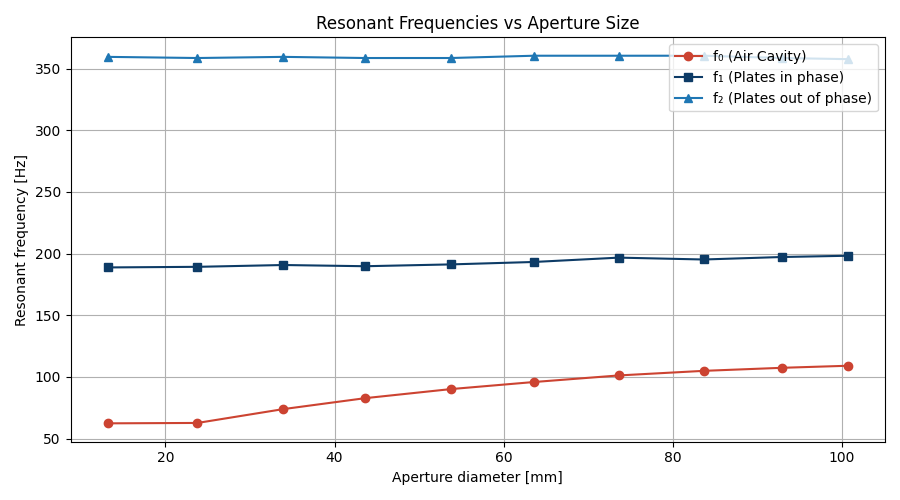

In [81]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(apertures, f0, 'o-', label='f₀ (Air Cavity)', color=c1)
ax.plot(apertures, f1, 's-', label='f₁ (Plates in phase)', color=c2)
ax.plot(apertures, f2, '^-', label='f₂ (Plates out of phase)')
ax.set_xlabel('Aperture diameter [mm]')
ax.set_ylabel('Resonant frequency [Hz]')
ax.set_title('Resonant Frequencies vs Aperture Size')
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

plt.savefig(plt_path + "/" + "res_freqs_vs_aper" + ".png")

### Helmholtz Resonance vs. Aperture Size

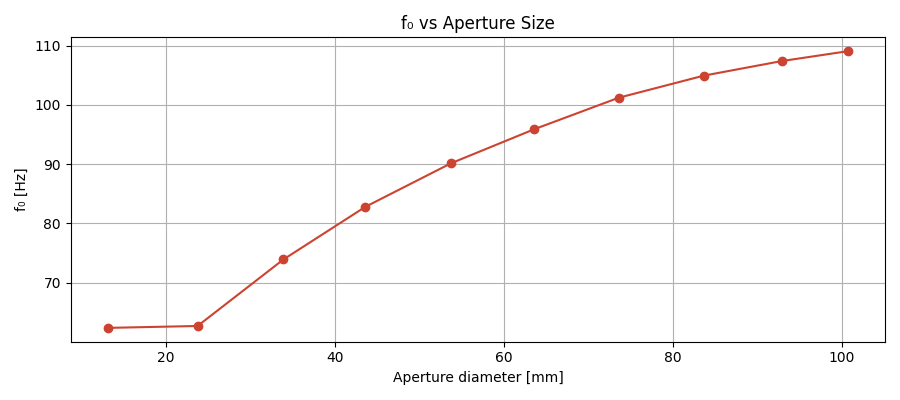

In [82]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(apertures, f0, 'o-', color=c1)
ax.set_xlabel('Aperture diameter [mm]')
ax.set_ylabel('f₀ [Hz]')
ax.set_title('f₀ vs Aperture Size')

plt.tight_layout()
plt.show()

plt_path = "C:/Users/Cassidy/OneDrive - Massachusetts Institute of Technology/Desktop/classes/21M.369/Final Project/data_analysis/plots"
fig.savefig(plt_path + "/" + "helm_vs_aper" + ".png")

### Helmholtz Resonancec vs. Aperture Size^(1/2)

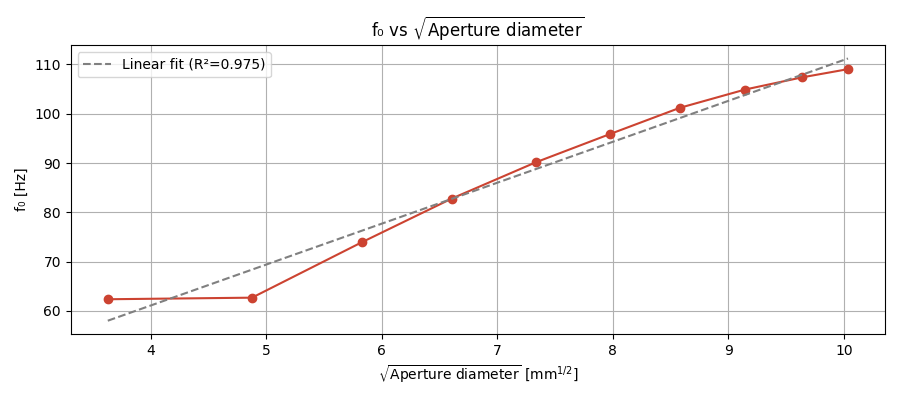

In [83]:
import numpy as np

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.sqrt(apertures), f0, 'o-', color=c1)

# Fit a line
coeffs = np.polyfit(np.sqrt(apertures), f0, 1)
x_fit = np.linspace(min(np.sqrt(apertures)), max(np.sqrt(apertures)), 100)
ax.plot(x_fit, np.polyval(coeffs, x_fit), '--', color='gray', label=f'Linear fit (R²={np.corrcoef(np.sqrt(apertures), f0)[0,1]**2:.3f})')

ax.set_xlabel(r'$\sqrt{\text{Aperture diameter}} \text{ [mm}^{1/2}\text{]}$')
ax.set_ylabel('f₀ [Hz]')
title = "f₀ vs " + r"$\sqrt{\text{Aperture diameter}}$"
ax.set_title(title)
ax.legend()

plt.tight_layout()
plt.show()

plt_path = "C:/Users/Cassidy/OneDrive - Massachusetts Institute of Technology/Desktop/classes/21M.369/Final Project/data_analysis/plots"
fig.savefig(plt_path + "/" + "helm_vs_sqrt_aper" + ".png")